# Lecture 25 - Self-Driving Labs

## Learning goals

After working through this notebook you should be able to

- Explain what a **self driving lab** is and list its main components.
- Build a simple **closed loop optimization** loop over a toy objective.
- Map abstract conditions into plate based experiments for a **liquid handler**.
- Sketch how a **multimodal lab agent** could coordinate search, images, and text.

[![Colab](https://img.shields.io/badge/Open-Colab-orange)](https://colab.research.google.com/drive/14JeDtDkgp2O3P9Xg7oZdGDj-E2EBazGU?usp=sharing)




## 1. Setup and API key

We begin with imports and an API key placeholder.

For security in real projects you should read your key from an environment variable or a local `.env` file, not hard code it into notebooks.

For classroom use we place a placeholder here so that the rest of the code is easier to read. When you adapt this notebook for your own work, replace this section with your preferred way of storing secrets.


In [93]:
# 1.1 Standard Python and scientific libraries

import os
import math
import json
import random
from datetime import datetime
from io import BytesIO
import numpy as np
from scipy.io.wavfile import write
from IPython.display import Audio, display
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from PIL import Image

# In real life: NEVER commit a real key to gitHub.

from openai import OpenAI

api_key = "___add___your____API____key___here"

# If you want to override this with your own key, uncomment the next line
# api_key = os.environ.get("OPENAI_API_KEY", api_key)

client = OpenAI(api_key=api_key)

## 2. What is a self driving lab

In this lecture we will connect everything you have seen so far about data, models, and large language models to the idea of a **self driving laboratory**.

A **self driving lab** is a closed loop system that

- chooses the next experiment to run,
- sends commands to instruments or robots,
- measures the outcome,
- updates its internal model of the system,
- and repeats until some goal is reached.

We will start from simple Python representations and toy objective functions, then move toward LLM based agents that can call tools such as web search and cameras.

At a high level, a self driving lab has four main components:

1. **Planner** - chooses the next experiment based on past data.
2. **Executor** - translates abstract conditions into concrete instrument actions.
3. **Sensor or analyzer** - measures experimental outcomes and converts raw data to numbers.
4. **Optimizer** - updates a model and decides whether to continue or stop.

You can think of the loop as repeatedly applying a function

$$(x_t, y_t) \rightarrow x_{t+1}$$

where

- $x_t$ is a set of experimental settings (temperature, concentration, etc),
- $y_t$ is the outcome (yield, selectivity, or any metric you care about).

The important point is that the loop is **closed**: experimental results immediately influence what happens next.

In this section we represent the four components as a simple Python dictionary so you can see their roles in a very compact form.


In [51]:
# 2.1 Represent the main components as a Python dict

components = {
    "planner": [
        "Choose candidate experiments from the design space",
        "Use past data to balance exploration and exploitation",
    ],
    "executor": [
        "Translate settings into instrument commands",
        "Talk to robots, pumps, heaters, or plate handlers",
    ],
    "analyzer": [
        "Collect raw data such as spectra, images, or currents",
        "Convert raw data into numeric metrics y",
    ],
    "optimizer": [
        "Fit a model y = f(x) from data so far",
        "Decide when to stop and when to continue",
    ],
}

for name, tasks in components.items():
    print(name.upper())
    for t in tasks:
        print("  -", t)
    print()


PLANNER
  - Choose candidate experiments from the design space
  - Use past data to balance exploration and exploitation

EXECUTOR
  - Translate settings into instrument commands
  - Talk to robots, pumps, heaters, or plate handlers

ANALYZER
  - Collect raw data such as spectra, images, or currents
  - Convert raw data into numeric metrics y

OPTIMIZER
  - Fit a model y = f(x) from data so far
  - Decide when to stop and when to continue



The dictionary above is not a real control system, but it captures the essential pieces in a few lines.

In real projects each item would correspond to many modules:

- The planner could be a Bayesian optimizer or an active learning model.
- The executor could be a microservice that writes CSV files for a liquid handler.
- The analyzer might fit calibration curves or peak shapes to spectroscopy data.
- The optimizer might enforce safety rules and resource limits.

In the next sections we gradually make these ideas concrete with small code examples.


## 3. Representing an experimental design space

A self driving lab has to pick experiments from some **design space**.

Mathematically, the design space is often a Cartesian product

$$X = X_1 \times X_2 \times \cdots \times X_d$$

where each $X_i$ is a set of allowed values for one factor, such as temperature or stoichiometry.

For example, a simple two factor design might look like

- $X_\text{temperature} = \{40, 60, 80\}$ in degrees Celsius,
- $X_\text{time} = \{1, 2, 4, 8\}$ in hours.

In code we usually represent such spaces with lists, dictionaries, and `pandas` DataFrames.

Let us build a small reaction design space for a hypothetical oxidation reaction.


In [52]:
# 3.1 Define ranges for a toy reaction design space

temperatures_C = [40, 60, 80]           # degrees Celsius
times_h = [1, 2, 4, 8]                  # hours
catalyst_loading_mol_percent = [1, 2, 5]
solvent = ["MeCN", "DMF"]

print("Temperatures:", temperatures_C)
print("Times:", times_h)
print("Catalyst loading:", catalyst_loading_mol_percent)
print("Solvent choices:", solvent)


Temperatures: [40, 60, 80]
Times: [1, 2, 4, 8]
Catalyst loading: [1, 2, 5]
Solvent choices: ['MeCN', 'DMF']


Each factor has a small number of discrete levels. In a full factorial design we would try every combination.

The size of the design space is the product of the number of levels in each factor.

In symbols

$$\lvert X \rvert = \lvert X_1 \rvert \times \lvert X_2 \rvert \times \cdots \times \lvert X_d \rvert$$

In code we can compute this by multiplying the lengths of the lists.


In [53]:
# 3.2 Count the number of possible experiments in the design space

n_T = len(temperatures_C)
n_t = len(times_h)
n_cat = len(catalyst_loading_mol_percent)
n_solv = len(solvent)

n_design_points = n_T * n_t * n_cat * n_solv

print("Total number of possible experiments:", n_design_points)


Total number of possible experiments: 72


This small toy space already contains several dozen possible experiments. Real self driving labs often work with thousands or millions of combinations.

To make the design space easy to inspect we create a `pandas` DataFrame where each row is one candidate experiment.


In [54]:
# 3.3 Build a DataFrame of all combinations

design_rows = []

for T in temperatures_C:
    for time_h in times_h:
        for cat in catalyst_loading_mol_percent:
            for solv in solvent:
                row = {
                    "T_C": T,
                    "time_h": time_h,
                    "cat_mol_percent": cat,
                    "solvent": solv,
                }
                design_rows.append(row)

design_df = pd.DataFrame(design_rows)
design_df.head()


,T_C,time_h,cat_mol_percent,solvent
0,40,1,1,MeCN
1,40,1,1,DMF
2,40,1,2,MeCN
3,40,1,2,DMF
4,40,1,5,MeCN


The table shows each candidate experiment as a row with four columns.

For example, the first row corresponds to

- temperature 40 degrees Celsius,
- time 1 hour,
- catalyst loading 1 mol percent,
- solvent MeCN.

The planner part of a self driving lab will repeatedly choose rows from `design_df` based on past outcomes. In the next section we create a simple synthetic function that plays the role of the real experiment.


## 4. A toy closed loop optimizer

Real experiments can be slow and expensive, so it is common to test ideas with **simulated objectives**.

We now define a simple function that maps a temperature and time to a "yield" between 0 and 1. This function acts as our hidden ground truth.

You can think of it as

$$y = f(T, t) + \epsilon$$

where

- $f(T, t)$ is a smooth function with a sweet spot,
- $\epsilon$ is small random noise that makes the problem realistic.


In [55]:
# 4.1 Define a synthetic objective function for yield

def synthetic_yield(T_C, time_h, noise_std=0.03, random_state=None):
    rng = np.random.default_rng(random_state)

    # Center around T_opt and t_opt
    T_opt = 70.0
    t_opt = 4.0

    # Widths control how sharp the optimum is
    sigma_T = 12.0
    sigma_t = 1.5

    # Gaussian shaped peak in two dimensions
    val = math.exp(-((T_C - T_opt) ** 2) / (2 * sigma_T ** 2)
                   - ((time_h - t_opt) ** 2) / (2 * sigma_t ** 2))

    # Clip to [0, 1] and add small noise
    noisy_val = max(0.0, min(1.0, val + rng.normal(0.0, noise_std)))
    return noisy_val

# Test the function at a few points
for T in [40, 60, 80]:
    for t in [1, 4, 8]:
        y = synthetic_yield(T, t, random_state=42)
        print(f"T = {T:3.0f} C, t = {t:2.0f} h -> yield ~ {y:0.3f}")


T =  40 C, t =  1 h -> yield ~ 0.015
T =  40 C, t =  4 h -> yield ~ 0.053
T =  40 C, t =  8 h -> yield ~ 0.010
T =  60 C, t =  1 h -> yield ~ 0.105
T =  60 C, t =  4 h -> yield ~ 0.716
T =  60 C, t =  8 h -> yield ~ 0.029
T =  80 C, t =  1 h -> yield ~ 0.105
T =  80 C, t =  4 h -> yield ~ 0.716
T =  80 C, t =  8 h -> yield ~ 0.029


The printed yields should be small near the corners and highest near the region around $T \approx 70$ degrees Celsius and $t \approx 4$ hours.

To see the shape more clearly we evaluate the function on a grid and plot a contour map. This mimics what would be hidden inside a real experiment, except we can peek behind the curtain here.


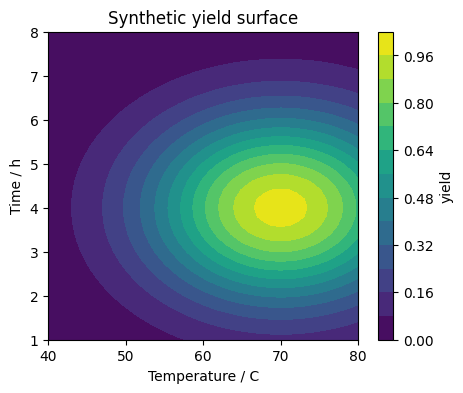

In [56]:
# 4.2 Visualize the synthetic objective on a grid

T_grid = np.linspace(40, 80, 41)
t_grid = np.linspace(1, 8, 36)

YY = np.zeros((len(t_grid), len(T_grid)))
for i, t in enumerate(t_grid):
    for j, T in enumerate(T_grid):
        YY[i, j] = synthetic_yield(T, t, noise_std=0.0)

T_mesh, t_mesh = np.meshgrid(T_grid, t_grid)

plt.figure(figsize=(5, 4))
contour = plt.contourf(T_mesh, t_mesh, YY, levels=15)
plt.xlabel("Temperature / C")
plt.ylabel("Time / h")
plt.title("Synthetic yield surface")
plt.colorbar(contour, label="yield")
plt.show()


In a real self driving lab you never see this contour plot. The optimizer only sees points that have been sampled so far.

We now implement a very simple closed loop:

1. Start with a small number of random experiments.
2. Evaluate the synthetic yield.
3. Keep track of the best result so far.
4. Suggest new experiments near the best point by adding small random steps.

This is not meant to be an optimal algorithm. It just gives you a concrete loop to study.


In [57]:
# 4.3 Simple closed loop search around the current best point

rng = np.random.default_rng(0)

def propose_neighbor(current_T, current_t, step_T=8.0, step_t=1.0):
    """Propose a new point near the current one by adding random offsets."""
    new_T = current_T + rng.normal(0.0, step_T)
    new_t = current_t + rng.normal(0.0, step_t)
    # Clip into the allowed range
    new_T = float(np.clip(new_T, 40.0, 80.0))
    new_t = float(np.clip(new_t, 1.0, 8.0))
    return new_T, new_t

history = []

# Initial random experiments
for i in range(3):
    T0 = float(rng.uniform(40.0, 80.0))
    t0 = float(rng.uniform(1.0, 8.0))
    y0 = synthetic_yield(T0, t0, random_state=rng.integers(0, 10_000))
    history.append({"T_C": T0, "time_h": t0, "yield": y0})

# Closed loop iterations
for step in range(10):
    # Find the best point so far
    best_row = max(history, key=lambda row: row["yield"])
    T_best = best_row["T_C"]
    t_best = best_row["time_h"]

    T_new, t_new = propose_neighbor(T_best, t_best)
    y_new = synthetic_yield(T_new, t_new, random_state=rng.integers(0, 10_000))
    history.append({"T_C": T_new, "time_h": t_new, "yield": y_new})

    print(f"Step {step:2d} -> new T = {T_new:5.1f} C, t = {t_new:4.1f} h, yield = {y_new:0.3f}")

history_df = pd.DataFrame(history)


Step  0 -> new T =  59.8 C, t =  1.6 h, yield = 0.179
Step  1 -> new T =  60.5 C, t =  2.9 h, yield = 0.557
Step  2 -> new T =  63.7 C, t =  1.6 h, yield = 0.218
Step  3 -> new T =  59.6 C, t =  2.3 h, yield = 0.395
Step  4 -> new T =  68.8 C, t =  3.9 h, yield = 0.973
Step  5 -> new T =  67.7 C, t =  5.3 h, yield = 0.728
Step  6 -> new T =  71.6 C, t =  4.8 h, yield = 0.839
Step  7 -> new T =  69.5 C, t =  3.2 h, yield = 0.873
Step  8 -> new T =  65.1 C, t =  4.2 h, yield = 0.857
Step  9 -> new T =  60.7 C, t =  3.7 h, yield = 0.719


The loop prints each new point and its yield. You should see yields gradually climb toward the region of high values.

It is often helpful to visualize where the loop has sampled in the $(T, t)$ plane.

We overlay the sample points on top of the contour plot of the synthetic surface. In a real lab you would only see the points, not the full background.


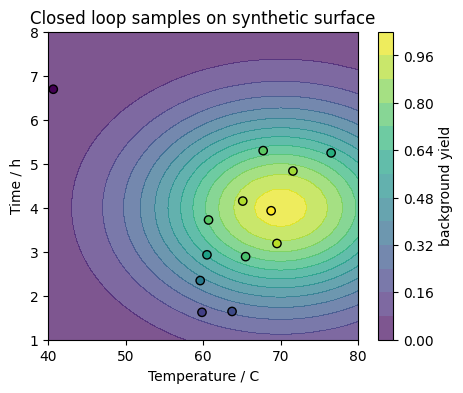

In [58]:
# 4.4 Plot sampled points on top of the synthetic surface

plt.figure(figsize=(5, 4))
contour = plt.contourf(T_mesh, t_mesh, YY, levels=15, alpha=0.7)
plt.scatter(history_df["T_C"], history_df["time_h"], c=history_df["yield"], edgecolor="k")
plt.xlabel("Temperature / C")
plt.ylabel("Time / h")
plt.title("Closed loop samples on synthetic surface")
plt.colorbar(contour, label="background yield")
plt.show()


You just implemented a tiny self driving lab in a few lines of Python:

- The **design space** is the rectangle in $(T, t)$.
- The **experiment** is the call to `synthetic_yield`.
- The **planner** is the function `propose_neighbor` plus the loop that keeps the best sample.
- The **optimizer** is the logic that moves samples toward higher yield.

In the next sections we move from abstract numbers to more realistic details, such as plates and instrument files.


## 5. Mapping conditions to plates and wells

Most experimental chemistry today still runs in batches of vials, tubes, or wells.

In high throughput experimentation we often use 96 well plates. Each well is addressed by a row letter and column number, such as `A1` or `H12`.

A self driving lab has to map abstract conditions like

> T = 60 C, time = 4 h, catalyst loading = 2 mol percent

to a concrete **well** and **volume plan**.

In this section we build a small helper that assigns wells to rows of our design table and creates a simple visualization.


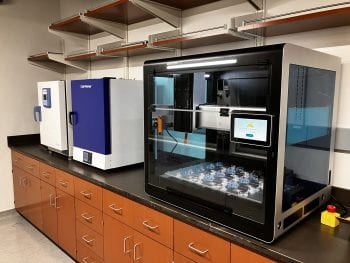

In [59]:
# 5.1 Helper functions for plate coordinates

rows_96 = list("ABCDEFGH")
cols_96 = list(range(1, 13))

def well_name_from_index(index):
    """Convert an integer index 0..95 to a well name like A1 or H12."""
    if index < 0 or index >= 96:
        raise ValueError("Index must be between 0 and 95.")
    row = rows_96[index // 12]
    col = cols_96[index % 12]
    return f"{row}{col}"

# Test mapping on a few indices
for idx in [0, 1, 11, 12, 95]:
    print(idx, "->", well_name_from_index(idx))


0 -> A1
1 -> A2
11 -> A12
12 -> B1
95 -> H12


The mapping uses integer division and modulo to walk through rows and columns.

Now we create a tiny design with at most 96 experiments and assign each to a well. For visualization, we take the first 30 experiments from `design_df`.


In [60]:
# 5.2 Assign wells to the first 30 design points

plate_df = design_df.head(30).copy()
plate_df = plate_df.reset_index(drop=True)

plate_df["well"] = [well_name_from_index(i) for i in range(len(plate_df))]

plate_df.head()


,T_C,time_h,cat_mol_percent,solvent,well
0,40,1,1,MeCN,A1
1,40,1,1,DMF,A2
2,40,1,2,MeCN,A3
3,40,1,2,DMF,A4
4,40,1,5,MeCN,A5


Each row now has a `well` column.

To see how the wells are filled, we build a simple heatmap where filled wells are colored and empty wells are left blank.


1 means used, 0 means empt


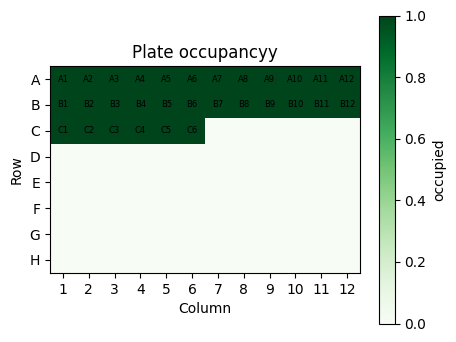

In [61]:
# 5.3 Visualize plate occupancy for the first 30 wells

occupancy = np.zeros((8, 12), dtype=int)

for i in range(len(plate_df)):
    idx = i
    r = idx // 12
    c = idx % 12
    occupancy[r, c] = 1

print("1 means used, 0 means empt")
plt.figure(figsize=(5, 4))
plt.imshow(occupancy, cmap="Greens", vmin=0, vmax=1)
plt.xticks(np.arange(12), cols_96)
plt.yticks(np.arange(8), rows_96)
plt.xlabel("Column")
plt.ylabel("Row")
plt.title("Plate occupancyy")
for r in range(8):
    for c in range(12):
        if occupancy[r, c] == 1:
            label = f"{rows_96[r]}{cols_96[c]}"
            plt.text(c, r, label, ha="center", va="center", fontsize=6)
plt.colorbar(label="occupied")
plt.show()


This picture is a very simple sketch, but the pattern is exactly what a real liquid handler would see when you send a plate layout file.

In practice you might

- reserve certain rows for controls,
- block out wells that are known to leak,
- or distribute conditions to avoid systematic gradients across the plate.

All of this logic can be expressed in Python before sending a final CSV or XML file to the instrument.


## 6. Generating a liquid handler CSV

Many commercial liquid handlers accept CSV files that describe how much volume to transfer from which stock positions to which wells.

The exact format is instrument specific. Here we use a simplified version inspired by the `generate_tecan_csv` helper shown in the class notes.

The idea is to

1. Define a small library of stock solutions grouped into categories.
2. Generate all combinations of stock choices.
3. For each reaction and each stock, write a row describing the transfer.

We do not need a special Tecan Python module for this. Regular Python and `csv` are enough.


In [62]:
# 6.1 A very small version of generate_tecan_csv

import csv

def generate_tecan_csv(
    plate_positions,
    stock_position=1,
    cat_A=None,
    cat_B=None,
    cat_C=None,
    cat_D=None,
    cat_E=None,
    amounts=None,
    filename="tecan_operations_small.csv",
):
    """Generate a simple CSV for a hypothetical Tecan robotic liquid handler.

    Parameters
    ----------
    plate_positions : list of int
        Plate identifiers such as [1] or [1, 2].
    stock_position : int
        Identifier for the stock labware, for example 1.
    cat_A ... cat_E : list of str
        Codes for stock solutions in each category.
    amounts : list of float
        Volume in microliter for each category, same order as A..E.
    filename : str
        Name of the CSV file to write in the current folder.
    """

    if cat_A is None:
        cat_A = ["I1", "I2"]
    if cat_B is None:
        cat_B = ["H1", "H2"]
    if cat_C is None:
        cat_C = ["P1"]
    if cat_D is None:
        cat_D = ["C1"]
    if cat_E is None:
        cat_E = ["EtOH"]
    if amounts is None:
        amounts = [25, 11, 6, 20, 60]

    categories = {"A": cat_A, "B": cat_B, "C": cat_C, "D": cat_D, "E": cat_E}
    volumes = {"A": amounts[0], "B": amounts[1], "C": amounts[2], "D": amounts[3], "E": amounts[4]}

    # Assign positions in the stock rack
    stock_codes = cat_A + cat_B + cat_C + cat_D + cat_E
    stock_positions = {code: idx + 1 for idx, code in enumerate(stock_codes)}

    # Generate combinations of codes
    combinations = []
    for a in cat_A:
        for b in cat_B:
            for c in cat_C:
                for d in cat_D:
                    for e in cat_E:
                        combinations.append((a, b, c, d, e))

    max_reactions = len(plate_positions) * 96
    if len(combinations) > max_reactions:
        print("Warning: more combinations than wells. Truncating.")
        combinations = combinations[:max_reactions]

    rows = []
    for i, combo in enumerate(combinations):
        plate_id = plate_positions[i // 96]
        well_num = i % 96 + 1
        assay = f"Assay {plate_id}"
        for letter, code in zip(["A", "B", "C", "D", "E"], combo):
            labware = f"Labware{stock_position}"
            pos = stock_positions[code]
            volume = volumes[letter]
            rows.append([labware, pos, assay, well_num, volume])

    with open(filename, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerows(rows)

    print(f"CSV saved as {filename}. Number of reaction conditions: {len(combinations)}")
    print("Number of pipetting actions:", len(rows))
    return filename

# Try the helper with a single plate
csv_path = generate_tecan_csv(plate_positions=[1])


CSV saved as tecan_operations_small.csv. Number of reaction conditions: 4
Number of pipetting actions: 20


The helper above is intentionally small.

- It assumes there is exactly one stock labware and a fixed number of categories.
- It writes rows with five columns: stock labware, stock position, assay id, well number, and volume.
- It truncates combinations if you ask for more reactions than wells.

Even in this compact form it illustrates an important point: **instrument files are just structured text**. Once you know the format, you can generate them from your design space with a few loops.

To inspect the content, we load the CSV into a `pandas` DataFrame and show the first few rows.


In [63]:
# 6.2 Inspect a small sample of the generated CSV

tecan_df = pd.read_csv(csv_path, header=None)
tecan_df.columns = ["labware", "stock_pos", "assay", "well", "volume_uL"]
tecan_df.head(10)


,labware,stock_pos,assay,well,volume_uL
0,Labware1,1,Assay 1,1,25
1,Labware1,3,Assay 1,1,11
2,Labware1,5,Assay 1,1,6
3,Labware1,6,Assay 1,1,20
4,Labware1,7,Assay 1,1,60
5,Labware1,1,Assay 1,2,25
6,Labware1,4,Assay 1,2,11
7,Labware1,5,Assay 1,2,6
8,Labware1,6,Assay 1,2,20
9,Labware1,7,Assay 1,2,60


Each row describes a single pipetting action. For instance, the first row might say

> take volume from stock position 1 in Labware1 and add it to well 1 of Assay 1, amount 25 uL

In real self driving labs the planner might propose a batch of experiments, then the executor would call a function like `generate_tecan_csv` to materialize those plans as robot commands.

### 6.3 Stock consumption summary

Before running a large batch of experiments, it is wise to check how much volume of each stock solution will be consumed.

Given a CSV like the one produced by `generate_tecan_csv`, you can group by stock position and sum the requested volume. If some stock would run dry, you can adjust your design before sending commands to the robot.

The small helper below computes stock level summaries and visualizes them as a bar chart.

Total volume per stock position:


,stock_pos,volume_uL
0,1,50
1,2,50
2,3,22
3,4,22
4,5,24
5,6,80
6,7,240


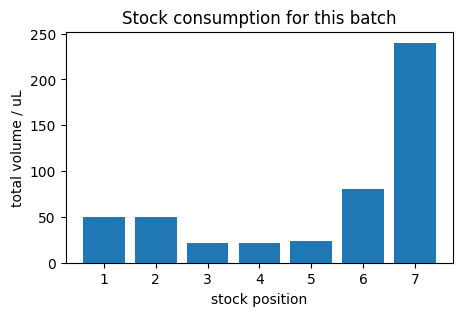

In [64]:
# 6.3.1 Summarize volume usage per stock position

summary = (
    tecan_df.groupby("stock_pos")["volume_uL"]
    .sum()
    .reset_index()
    .sort_values("stock_pos")
)

print("Total volume per stock position:")
display(summary)

plt.figure(figsize=(5, 3))
plt.bar(summary["stock_pos"], summary["volume_uL"])
plt.xlabel("stock position")
plt.ylabel("total volume / uL")
plt.title("Stock consumption for this batch")
plt.show()


### 6.4 Rough estimate of schedule time

Liquid handlers and other robots have finite speed.

If you know approximately how long one pipetting action takes, you can estimate how long a batch of experiments will require. This is helpful when planning overnight runs or deciding whether to split a campaign into several smaller batches.

The calculation is simple

$$t_\text{total} = N_\text{actions} \times t_\text{per action}$$

where

- $N_\text{actions}$ is the number of rows in the CSV file,
- $t_\text{per action}$ is an average duration per transfer.

In [65]:
# 6.4.1 Estimate total run time from number of actions

n_actions = len(tecan_df)
seconds_per_action = 10   # adjust to your instrument
total_seconds = n_actions * seconds_per_action
total_minutes = total_seconds / 60.0

print(f"Number of pipetting actions: {n_actions}")
print(f"Estimated total time: {total_minutes:0.1f} minutes")

if total_minutes > 120:
    print("Hint: consider splitting this into multiple plates or batches.")


Number of pipetting actions: 20
Estimated total time: 3.3 minutes



In the next section we introduce simple helpers for monitoring the outcome of those experiments using cameras.


## 7. Monitoring experiments with cameras

Self driving labs often use cameras to monitor instruments and experiments.

Examples include

- taking pictures of a liquid handler deck to check that plates are present,
- monitoring the color or turbidity of reactions over time,
- reading sample identifiers from labels or barcodes.

In this section we define two helpers

- `capture_image` - fetches an image from a fixed URL and saves it locally,
- `image_to_base64` - converts an image file to a base64 string so it can be sent to an LLM.

For illustration, the `capture_image` helper fetches an image hosted on GitHub. In your own lab you would replace the URL with a camera endpoint.


In [66]:
"""
response = client.responses.create(
    model="gpt-4.1-mini",
    input=[{
        "role": "user",
        "content": [
            {"type": "input_text", "text": "what's in this image?"},
            {
                "type": "input_image",
                "image_url": "https://upload.wikimedia.org/wikipedia/commons/thumb/d/dd/Gfp-wisconsin-madison-the-nature-boardwalk.jpg/2560px-Gfp-wisconsin-madison-the-nature-boardwalk.jpg",
            },
        ],
    }],
)

print(response.output_text)
"""

'\nresponse = client.responses.create(\n    model="gpt-4.1-mini",\n    input=[{\n        "role": "user",\n        "content": [\n            {"type": "input_text", "text": "what\'s in this image?"},\n            {\n                "type": "input_image",\n                "image_url": "https://upload.wikimedia.org/wikipedia/commons/thumb/d/dd/Gfp-wisconsin-madison-the-nature-boardwalk.jpg/2560px-Gfp-wisconsin-madison-the-nature-boardwalk.jpg",\n            },\n        ],\n    }],\n)\n\nprint(response.output_text)\n'

In [67]:
# 7.1 Helper to capture an image from a fixed URL

CAMERA_IMAGE_URL = "https://raw.githubusercontent.com/zzhenglab/ai4chem/main/book/_data/camera_photo_live.jpg"

def capture_image(filename=None):
    """Fetch an image from CAMERA_IMAGE_URL and save it locally.

    In the teaching setup this URL simulates a live camera snapshot.

    Parameters
    ----------
    filename : str or None
        If given, use this name. Otherwise build one from the current time.

    Returns
    -------
    path : str
        Path to the saved image file, or a message string on error.
    """
    if requests is None or Image is None:
        return "Requests or Pillow not available. Install them to use capture_image."

    if filename is None:
        now = datetime.now()
        filename = f"camera_{now.year}_{now.month:02d}_{now.day:02d}_{now.hour:02d}_{now.minute:02d}.jpg"

    try:
        resp = requests.get(CAMERA_IMAGE_URL, timeout=10)
        resp.raise_for_status()
    except Exception as e:
        return f"Error fetching image from URL: {e}"

    try:
        img = Image.open(BytesIO(resp.content))
        img.save(filename)
    except Exception as e:
        return f"Error decoding or saving image: {e}"

    return os.path.abspath(filename)

# Try capturing one image
image_path = capture_image()
print("Captured image path:", image_path)


Captured image path: /content/camera_2025_11_25_20_06.jpg


If the required packages are installed and you have network access, the cell above will create a JPEG file in your working folder.

To see what the image looks like inside the notebook, we open it with `Pillow` and display it with `matplotlib`.


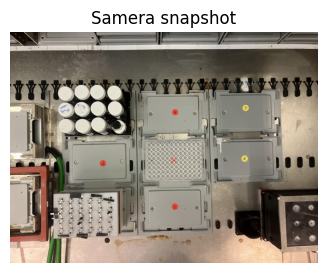

In [68]:
# 7.2 Display the captured image in the notebook

if isinstance(image_path, str) and os.path.isfile(image_path) and Image is not None:
    img = Image.open(image_path)
    plt.figure(figsize=(4, 3))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Samera snapshot")
    plt.show()
else:
    print("No local image file to display. Check previous messages for errors.")


When you integrate this kind of helper into a self driving lab, you typically

- capture an image before and after a run,
- store it with a timestamp and an experiment id,
- optionally pass it to a vision model to detect problems.

To send images to a multimodal LLM, you often need a base64 representation. The next helper converts an image file path into a base64 string.


In [69]:
# 7.3 Convert an image file to base64 text

import base64

def image_to_base64(image_path):
    """Read an image file and return a base64 encoded string."""
    try:
        with open(image_path, "rb") as f:
            encoded = base64.b64encode(f.read()).decode("utf-8")
        return encoded
    except Exception as e:
        return f"Error encoding image: {e}"

if isinstance(image_path, str) and os.path.isfile(image_path):
    b64_preview = image_to_base64(image_path)
    print("First 120 characters of base64 string:")
    print(b64_preview[:120] + "...")
else:
    print("Skipping base64 preview because image file is missing.")


First 120 characters of base64 string:
/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/...


You should see a long string starting with something like `iVBORw0...` or `/9j/4AAQSkZJRg...` depending on the image format.

This is exactly the type of string that the OpenAI API expects when you send an image as part of a multimodal prompt.

In a real lab you might have more sophisticated monitoring functions that scan folders and select the most recent image for a given piece of equipment. For completeness, here is a tiny sketch that searches a folder for `.jpg` files and returns the newest one.


In [70]:
# 7.4 Sketch of an equipment monitoring helper

def monitor_equipment_status(folder="."):
    """Return the path of the newest .jpg file in a folder.

    In a real lab you might dedicate one folder per instrument.
    Here we just look into the current working directory.
    """
    if not os.path.isdir(folder):
        return f"Folder {folder!r} does not exist."

    jpg_files = [f for f in os.listdir(folder) if f.lower().endswith(".jpg")]
    if not jpg_files:
        return "No .jpg files found."

    # Sort by modification time and pick the latest one
    jpg_paths = [os.path.join(folder, f) for f in jpg_files]
    jpg_paths.sort(key=lambda p: os.path.getmtime(p), reverse=True)
    latest = jpg_paths[0]
    return latest

latest_image = monitor_equipment_status(".")
print("Latest jpg file in this folder:", latest_image)


Latest jpg file in this folder: ./camera_2025_11_25_20_06.jpg


This helper is deliberately simple, but it shows how you can start to view your file system as a sensor.

Next we combine these monitoring ideas with language models so that an agent can decide when to capture images or query the web.


## 8. LLM based planners and custom tools

So far our planner for the synthetic reaction has been very simple and hard coded.

Modern language models give us an interesting alternative: we can ask a model to **propose new experiments** in natural language, and even give it access to external tools such as

- web search,
- `capture_image` for checking instruments,
- CSV generators for robots.

In this section you will

- recall how to make a plain text call with `client.responses.create`,
- define helper tools such as `web_search`,
- see how GPT 5.1 can call custom tools using the Responses API.

We will not build a fully autonomous agent, but you will see enough pieces to understand how such an agent would work.


In [71]:
# 8.1 Plain text call with the Responses API

prompt = "In one sentence, describe what a self driving chemistry lab does."

response = client.responses.create(
    model="gpt-5.1",
    input=prompt,
    reasoning={"effort": "low"},
    text={"verbosity": "low"},
)

print("Model reply:")
print(response.output_text)


Model reply:
A self-driving chemistry lab is an automated, AI-guided system that designs, runs, and analyzes chemical experiments on its own, continually learning to improve future experiments.


The call above uses the new Responses API.

- `model="gpt-5.1"` chooses a reasoning capable model.
- `input` is a simple string, but it could also be a list of role based messages.
- `reasoning` optional settings ask the model to do a small amount of internal reasoning.
- `text` controls verbosity of the final answer.

Now we define a tiny `web_search` tool using the `duckduckgo_search` package. This will allow an agent to pull in recent information when deciding what experiments to run.


In [72]:
# 8.2 A simple web_search helper using DuckDuckGo

def web_search(query):
    """Return search result done by gpt.
    """
    response = client.responses.create(
    model="gpt-5.1",
    reasoning={"effort": "low"},
    tools=[
      {
          "type": "web_search",
          "filters": {
              "allowed_domains": [
                  "pubmed.ncbi.nlm.nih.gov",
                  "www.google.com"
              ]
          },
      }
  ],
    tool_choice="auto",
    include=["web_search_call.action.sources"],
    input=query,
    instructions = "Answer in 3 sentences." #try to make it fast
)
    return response.output_text

# Try the helper on a chemistry related query
demo_results = web_search("what's today's date? show me the title of a JACS paper published in 2024.")
print(demo_results)


Today’s date is Tuesday, November 25, 2025.  
One example of a JACS paper published in 2024 is titled “Pyridine-based strategies towards nitrogen isotope exchange and multiple isotope incorporation.” ([pubmed.ncbi.nlm.nih.gov](https://pubmed.ncbi.nlm.nih.gov/39025881/?utm_source=openai))  
If you’d like a title from a particular subfield (e.g., organometallics, catalysis, materials), tell me your area and I can pick something more targeted.


In [73]:
def analyze_camera_image(query):
  """Return image analysis done by gpt."""
  response = client.responses.create(
  model="gpt-5.1",
  input=[{
        "role": "user",
        "content": [
            {"type": "input_text", "text": "Be very detailed and specific about objects and positions. Answer in three sentences" + query},
            {
                "type": "input_image",
                "image_url": "https://raw.githubusercontent.com/zzhenglab/ai4chem/main/book/_data/camera_photo_live.jpg",
            },
        ],
    }],
  )
  return response.output_text

# Try the helper on a related query

demo_results2 = analyze_camera_image("what's in this image?")
print(demo_results2)

The image shows a metal work surface holding several modular lab components arranged in a grid, with six gray rectangular plates in the center and right labeled by colored circular stickers “2,” “4,” “6” (red) and “7,” “8” (yellow); in the middle of these is a clear 96‑well microplate with a red dot near its center. On the left central side, there is a black rack containing three rows of small bottles or vials with white caps, two of whose top labels have handwritten blue text, and below that is another gray module adjacent to a white and red component that has five parallel rows of small black fittings or connectors. Around the outer edges, there are black cable or tubing clips along the top and bottom, a green cable entering from the lower left, a red‑framed device at the far left, and a black and red box with six recessed circular features at the lower right corner.


In [74]:
from datetime import datetime
def check_time():
    """Return current local time as an ISO formatted string."""
    now = datetime.now()
    return now.isoformat()

check_time()

'2025-11-25T20:06:36.082221'

To allow GPT 5.1 to call functions such as `web_search` or `capture_image`, we describe them in a `tools` list that we pass to `client.responses.create`. The model can then decide whether to call a tool and with what arguments.

Below we start with a single tool for web search.


In [75]:
import json

lab_tools = [
    {
        "type": "function",
        "name": "web_search",
        "description": "Search the web for recent information relevant to experimental chemistry.",
        "parameters": {
            "type": "object",
            "properties": {
                "query": {
                    "type": "string",
                    "description": "The search query string.",
                },
                "max_results": {
                    "type": "integer",
                    "description": "Maximum number of search results to return.",
                    "default": 5,
                },
            },
            "required": ["query"],
        },
    },
    {
        "type": "function",
        "name": "analyze_camera_image",
        "description": "Ask the model to analyze the current camera image and answer a user query about it.",
        "parameters": {
            "type": "object",
            "properties": {
                "query": {
                    "type": "string",
                    "description": "The question or instruction about the image. For example, 'Describe all objects and their positions'.",
                }
            },
            "required": ["query"],
        },
    },
    {
        "type": "function",
        "name": "check_time",
        "description": "Return the current local time on the system running this code.",
        "parameters": {
            "type": "object",
            "properties": {},
            "required": [],
        },
    },
]
print(f"Number of tools GPT can use : {len(lab_tools)}")



Number of tools GPT can use : 3


The dictionary matches the JSON schema format you saw in the tool calling guide.

To see how this works with the Responses API, we follow the same pattern as the horoscope example from the documentation, but we replace the tool with `web_search`.

The interaction has three phases:

1. Ask the model what to do and inspect `response.output` for tool calls.
2. Execute the tool on the Python side.
3. Send the tool output back to the model so it can generate a final answer.

For classroom use we only run one round of this pattern to keep things understandable.


In [76]:
def run_lab_agent(conversation):
    """
    Run an interactive loop where GPT 5.1 can call web_search,
    analyze_camera_image, and check_time multiple times.

    Prints clear separators for each part of the process.
    """

    # Normalize the initial input
    if isinstance(conversation, str):
        full_input = [{"role": "user", "content": conversation}]
    else:
        full_input = list(conversation)

    print("========== INITIAL INPUT ==========")
    print(full_input)

    while True:
        print("\n========== MODEL RESPONSE ==========")

        response = client.responses.create(
            model="gpt-5.1",
            tools=lab_tools,
            input=full_input,
        )

        # Print raw model output (including any function calls)
        for item in response.output:
            print(item)

        # Add these messages to the ongoing conversation
        full_input += list(response.output)

        # Detect tool calls
        tool_calls = [
            item for item in response.output
            if getattr(item, "type", None) == "function_call"
        ]

        if not tool_calls:
            print("\n========== FINAL ANSWER ==========")
            return response

        # Execute all tool calls before looping again
        for call in tool_calls:
            args = json.loads(call.arguments or "{}")

            if call.name == "web_search":
                print("\n========== RUNNING TOOL: web_search ==========")
                query = args.get("query", "")
                max_results = int(args.get("max_results", 5))
                print("Query:", query)

                results = web_search(query, max_results=max_results)
                print("Tool output:", results)

                full_input.append({
                    "type": "function_call_output",
                    "call_id": call.call_id,
                    "output": json.dumps(results),
                })

            elif call.name == "analyze_camera_image":
                print("\n========== RUNNING TOOL: analyze_camera_image ==========")
                q = args.get("query", "")
                print("Query:", q)

                analysis = analyze_camera_image(q)
                print("Tool output:", analysis)

                full_input.append({
                    "type": "function_call_output",
                    "call_id": call.call_id,
                    "output": json.dumps({"analysis": analysis}),
                })

            elif call.name == "check_time":
                print("\n========== RUNNING TOOL: check_time ==========")

                current_time = check_time()
                print("Tool output:", current_time)

                full_input.append({
                    "type": "function_call_output",
                    "call_id": call.call_id,
                    "output": json.dumps({"current_time": current_time}),
                })

        print("\n========== TOOL OUTPUT SENT BACK TO MODEL ==========")
        print(full_input)
        print("\nLooping again...\n")


# Simple one shot question (model can use web_search and/or analyze_camera_image)
question = "what's the time now? What is on my robotic platform now?"

final_response = run_lab_agent(question)
print(final_response.output_text)

========== INITIAL INPUT ==========
[{'role': 'user', 'content': "what's the time now? What is on my robotic platform now?"}]

========== MODEL RESPONSE ==========
ResponseFunctionToolCall(arguments='{}', call_id='call_WxmGqfSXklSNSkcj3W15JjBI', name='check_time', type='function_call', id='fc_092b079931a62f300069260c4d2cf881a3b3d47dc6d39591d6', status='completed')
ResponseFunctionToolCall(arguments='{"query":"Describe what is currently on my robotic platform, including objects and their positions."}', call_id='call_p8CspavmANwFuGbTHt3MIWpW', name='analyze_camera_image', type='function_call', id='fc_092b079931a62f300069260c4d424c81a39dabb3ec33792fde', status='completed')

========== RUNNING TOOL: check_time ==========
Tool output: 2025-11-25T20:06:37.783085

========== RUNNING TOOL: analyze_camera_image ==========
Query: Describe what is currently on my robotic platform, including objects and their positions.
Tool output: On the left side, there is a black rack of twelve white‑capped bo

The pattern above is the core of many LLM based agents:

- The model plans a tool call.
- Python executes the tool.
- The model uses the tool output to answer the user.

The next step is to define custom tools that accept **freeform text** rather than strict JSON arguments. This is useful when the model needs to send code, SQL queries, or configuration snippets directly to a backend.


In [77]:

# Ask the model to generate code for the custom tool
response = client.responses.create(
    model="gpt-5",
    input="Use the code_exec tool to print hello world to the console.",
    tools=[
        {
            "type": "custom",
            "name": "code_exec",
            "description": "Executes arbitrary Python code.",
        }
    ]
)

# Extract tool call
tool_call = next(
    item for item in response.output
    if item.type == "custom_tool_call"
)

code_to_run = tool_call.input
print("Model provided code:")
print(code_to_run)

# EXECUTE THE CODE LOCALLY
print("\nTool execution result:")
exec(code_to_run)

Model provided code:
print("hello world")

Tool execution result:
hello world


When you set `type: "custom"`, the model can send any raw text as the tool input. This could be

- Python code that plots a figure,
- a shell command,
- or a small script that talks to your lab hardware.





In [78]:
# Custom tools with freeform inputs

response = client.responses.create(
    model="gpt-5.1",
    input="""Use the code_exec tool to do below
    Task:
  1. Use the 96-well plate layout with rows A–H and columns 1–12.
  2. Mark the first 26 wells (A1, A2, ..., as in standard row-major order) as occupied.
  3. Create a pandas DataFrame with columns: well, row, col, occupied (0 or 1).
  4. Save it as a CSV file called `plate_execution_plan.csv`.
  5. Create a matplotlib heatmap of plate occupancy similar to:
    """,
    tools=[
        {
            "type": "custom",
            "name": "code_exec",
            "description": "Executes arbitrary Python code.",
        }
    ]
)




# Extract tool call
tool_call = next(
    item for item in response.output
    if item.type == "custom_tool_call"
)

code_to_run = tool_call.input
print("Model provided code:")
print(code_to_run)

# EXECUTE THE CODE LOCALLY
print("\nTool execution result:")
exec(code_to_run)

Model provided code:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Define plate layout
rows = list("ABCDEFGH")
cols = list(range(1, 13))

wells = []
for r in rows:
    for c in cols:
        wells.append(f"{r}{c}")

# 2. Mark first 26 wells as occupied (row-major order)
occupied_wells = set(wells[:26])

# 3. Create DataFrame
data = []
for r in rows:
    for c in cols:
        well = f"{r}{c}"
        data.append({
            "well": well,
            "row": r,
            "col": c,
            "occupied": 1 if well in occupied_wells else 0
        })

df = pd.DataFrame(data)

# 4. Save as CSV
csv_filename = "plate_execution_plan.csv"
df.to_csv(csv_filename, index=False)

# 5. Create heatmap of plate occupancy
occupancy_matrix = df.pivot(index="row", columns="col", values="occupied")
# Ensure correct row order (A on top, H at bottom)
occupancy_matrix = occupancy_matrix.reindex(index=rows)

plt.figure(figsize=(8, 5))
im = plt.imshow(occupancy_matrix.values

### 8.6 Multimodal examples: images and audio

Recent models can also understand images and audio. Two short examples illustrate the syntax.

First, to generate an image you can call the Responses API with an `image_generation` tool.


In [86]:
# Image generation call sketch


response_img = client.responses.create(
     model="gpt-4.1-mini",
     input="Generate an image of a microtiter plate on a robot deck in a chemistry lab.",
     tools=[{"type": "image_generation"}],
 )

image_data = [
     output.result
     for output in response_img.output
     if output.type == "image_generation_call"
 ]

if image_data:
     image_base64 = image_data[0]
     with open("robot_plate.png", "wb") as f:
         f.write(base64.b64decode(image_base64))
     print("Saved generated image to robot_plate.png")


Saved generated image to robot_plate.png


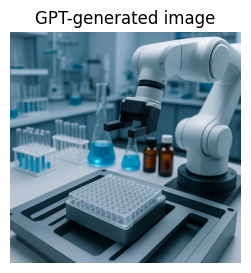

In [87]:
img = Image.open("robot_plate.png")
plt.figure(figsize=(4, 3))
plt.imshow(img)
plt.axis("off")
plt.title("GPT-generated image")
plt.show()

Second, you can use the `gpt-4o-audio-preview` model to work with audio input and output.

For instance, you could record a spoken question about a reaction and let the model answer with both text and synthetic speech.

The snippet below shows one example to implement this idea:


Now, we load this voice agent with the tools:

In [81]:
import json

lab_tools = [
    {
        "type": "function",
        "name": "web_search",
        "description": "Search the web for recent information relevant to experimental chemistry.",
        "parameters": {
            "type": "object",
            "properties": {
                "query": {
                    "type": "string",
                    "description": "The search query string.",
                },
                "max_results": {
                    "type": "integer",
                    "description": "Maximum number of search results to return.",
                    "default": 5,
                },
            },
            "required": ["query"],
        },
    },
    {
        "type": "function",
        "name": "analyze_camera_image",
        "description": "Ask the model to analyze the current camera image and answer a user query about it.",
        "parameters": {
            "type": "object",
            "properties": {
                "query": {
                    "type": "string",
                    "description": "The question or instruction about the image. For example, 'Describe all objects and their positions'.",
                }
            },
            "required": ["query"],
        },
    },
    {
        "type": "function",
        "name": "check_time",
        "description": "Return the current local time on the system running this code.",
        "parameters": {
            "type": "object",
            "properties": {},
            "required": [],
        },
    },
    {
        "type": "function",
        "name": "generate_tecan_csv",
        "description": "Generate a CSV for a Tecan liquid handler based on plate positions, stock layout, and category volumes.",
        "parameters": {
            "type": "object",
            "properties": {
                "plate_positions": {
                    "type": "array",
                    "items": {"type": "integer"},
                    "description": "List of plate identifiers such as [1] or [1, 2].",
                    "default": [1],
                },
                "stock_position": {
                    "type": "integer",
                    "description": "Identifier for the stock labware, for example 1.",
                    "default": 1,
                },
                "cat_A": {
                    "type": "array",
                    "items": {"type": "string"},
                    "description": "Codes for stock solutions in category A.",
                    "default": ["I1", "I2"],
                },
                "cat_B": {
                    "type": "array",
                    "items": {"type": "string"},
                    "description": "Codes for stock solutions in category B.",
                    "default": ["H1", "H2"],
                },
                "cat_C": {
                    "type": "array",
                    "items": {"type": "string"},
                    "description": "Codes for stock solutions in category C.",
                    "default": ["P1"],
                },
                "cat_D": {
                    "type": "array",
                    "items": {"type": "string"},
                    "description": "Codes for stock solutions in category D.",
                    "default": ["C1"],
                },
                "cat_E": {
                    "type": "array",
                    "items": {"type": "string"},
                    "description": "Codes for stock solutions in category E.",
                    "default": ["EtOH"],
                },
                "amounts": {
                    "type": "array",
                    "items": {"type": "number"},
                    "description": "Volumes in microliter for categories A..E, in order.",
                    "default": [25, 11, 6, 20, 60],
                },
                "filename": {
                    "type": "string",
                    "description": "Name of the CSV file to write in the current folder.",
                    "default": "tecan_operations_small.csv",
                },
            },
            "required": ["plate_positions"],
        },
    },
]

print(f"Number of tools GPT can use : {len(lab_tools)}")


Number of tools GPT can use : 4


In [ ]:
import json, io, contextlib

def run_code_exec(code_string):
    buf = io.StringIO()
    env = {}
    try:
        with contextlib.redirect_stdout(buf):
            exec(code_string, env, env)
        out = buf.getvalue()
        return out or "Code ran with no printed output."
    except Exception as e:
        return f"Error while running code: {e}"

# === Tool definitions (your lab_tools + code_exec) ===

code_exec_tool = {
    "type": "custom",
    "name": "code_exec",
    "description": "Executes arbitrary Python code.",
}

print(f"Number of tools GPT can use: {len(lab_tools)} (+ code_exec)")

# === Voice agent that uses lab_tools and code_exec ===

def voice_lab_agent(output_mode="text", seconds=5):
    """
    1) Record short audio from mic
    2) Transcribe with Whisper
    3) Let GPT 5.1 use web_search / analyze_camera_image / check_time and code_exec
    4) Reply in text or voice
    """
    audio_path = record_audio(seconds=seconds)

    # Speech to text
    with open(audio_path, "rb") as f:
        t = client.audio.transcriptions.create(
            model="whisper-1",
            file=f,
        )
    user_text = t.text
    print("You said:", user_text)
    system_msg = {
        "role": "system",
        "content": (
            "You are a laboratory assistant. You answer questions within three sentences."
        ),
    }


    tools_all = lab_tools + [code_exec_tool]
    full_input = [system_msg,{"role": "user", "content": user_text}]

    while True:
        resp = client.responses.create(
            model="gpt-5.1",
            input=full_input,
            tools=tools_all,
        )

        full_input += list(resp.output)

        fn_calls = [
            item for item in resp.output
            if getattr(item, "type", None) == "function_call"
        ]
        custom_calls = [
            item for item in resp.output
            if getattr(item, "type", None) == "custom_tool_call"
        ]

        if not fn_calls and not custom_calls:
            answer = resp.output_text
            break

        # Handle function tools
        for call in fn_calls:
            args = json.loads(call.arguments or "{}")

            if call.name == "web_search":
                res = web_search(
                    query=args.get("query", ""),
                )
                full_input.append({
                    "type": "function_call_output",
                    "call_id": call.call_id,
                    "output": json.dumps(res),
                })

            elif call.name == "analyze_camera_image":
                res = analyze_camera_image(args.get("query", ""))
                full_input.append({
                    "type": "function_call_output",
                    "call_id": call.call_id,
                    "output": json.dumps({"analysis": res}),
                })

            elif call.name == "check_time":
                res = check_time()
                full_input.append({
                    "type": "function_call_output",
                    "call_id": call.call_id,
                    "output": json.dumps({"current_time": res}),
                })

        # Handle code_exec custom tool
        for call in custom_calls:
            code_str = call.input or ""
            exec_result = run_code_exec(code_str)
            print("\n[code_exec output]\n", exec_result)
            full_input.append({
                "type": "custom_tool_output",
                "call_id": call.call_id,
                "output": exec_result,
            })

    # Final answer to user
    if output_mode == "voice":
        out_file = "voice_lab_agent_answer.mp3"
        with client.audio.speech.with_streaming_response.create(
            model="tts-1",
            voice="alloy",
            input=answer,
        ) as r:
            r.stream_to_file(out_file)
        display(Audio(out_file, autoplay=False))
    else:
        print("\nAssistant:", answer)

    return answer



Number of tools GPT can use: 4 (+ code_exec)


In [ ]:
import json, io, contextlib, subprocess, os

def run_code_exec(code_string):
    buf = io.StringIO()
    env = {}
    try:
        with contextlib.redirect_stdout(buf):
            exec(code_string, env, env)
        out = buf.getvalue()
        return out or "Code ran with no printed output."
    except Exception as e:
        return f"Error while running code: {e}"

# === Tool definitions (your lab_tools + code_exec) ===

code_exec_tool = {
    "type": "custom",
    "name": "code_exec",
    "description": "Executes arbitrary Python code.",
}

print(f"Number of tools GPT can use: {len(lab_tools)} (+ code_exec)")

def convert_to_wav(input_path: str) -> str:
    """
    Convert the recorded file to a plain WAV audio file for Whisper.
    Assumes ffmpeg is installed in the environment.
    """
    base, _ = os.path.splitext(input_path)
    output_path = base + ".wav"

    # -y overwrites without asking
    cmd = [
        "ffmpeg",
        "-i", input_path,
        "-vn",             # drop any video track
        "-acodec", "pcm_s16le",
        "-ar", "16000",    # 16 kHz mono is fine for speech
        "-ac", "1",
        output_path,
        "-y",
    ]
    subprocess.run(cmd, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return output_path

# === Voice agent that uses lab_tools and code_exec ===

def voice_lab_agent(output_mode="text", seconds=5):
    """
    1) Record short audio from mic
    2) Transcribe with Whisper
    3) Let GPT 5.1 use web_search / analyze_camera_image / check_time and code_exec
    4) Reply in text or voice
    """
    audio_path = record_audio(seconds=seconds)

    # Convert to WAV to avoid "Invalid file format" issues
    try:
        wav_path = convert_to_wav(audio_path)
        audio_path_for_whisper = wav_path
    except Exception as e:
        print("Conversion to WAV failed, falling back to original file:", e)
        audio_path_for_whisper = audio_path

    # Speech to text
    with open(audio_path_for_whisper, "rb") as f:
        t = client.audio.transcriptions.create(
            model="whisper-1",
            file=f,
        )
    user_text = t.text
    print("You said:", user_text)

    system_msg = {
        "role": "system",
        "content": (
            "You are a laboratory assistant. You answer questions within three sentences."
        ),
    }

    tools_all = lab_tools + [code_exec_tool]
    full_input = [system_msg, {"role": "user", "content": user_text}]

    while True:
        resp = client.responses.create(
            model="gpt-5.1",
            input=full_input,
            tools=tools_all,
        )

        full_input += list(resp.output)

        fn_calls = [
            item for item in resp.output
            if getattr(item, "type", None) == "function_call"
        ]
        custom_calls = [
            item for item in resp.output
            if getattr(item, "type", None) == "custom_tool_call"
        ]

        if not fn_calls and not custom_calls:
            answer = resp.output_text
            break

        # Handle function tools
        for call in fn_calls:
            args = json.loads(call.arguments or "{}")

            if call.name == "web_search":
                res = web_search(
                    query=args.get("query", ""),
                )
                full_input.append({
                    "type": "function_call_output",
                    "call_id": call.call_id,
                    "output": json.dumps(res),
                })

            elif call.name == "analyze_camera_image":
                res = analyze_camera_image(args.get("query", ""))
                full_input.append({
                    "type": "function_call_output",
                    "call_id": call.call_id,
                    "output": json.dumps({"analysis": res}),
                })

            elif call.name == "check_time":
                res = check_time()
                full_input.append({
                    "type": "function_call_output",
                    "call_id": call.call_id,
                    "output": json.dumps({"current_time": res}),
                })

        # Handle code_exec custom tool
        for call in custom_calls:
            code_str = getattr(call, "input", "") or ""
            exec_result = run_code_exec(code_str)
            print("\n[code_exec output]\n", exec_result)
            full_input.append({
                "type": "custom_tool_output",
                "call_id": call.call_id,
                "output": exec_result,
            })

    # Final answer to user
    if output_mode == "voice":
        out_file = "voice_lab_agent_answer.mp3"
        with client.audio.speech.with_streaming_response.create(
            model="tts-1",
            voice="alloy",
            input=answer,
        ) as r:
            r.stream_to_file(out_file)
        display(Audio(out_file, autoplay=False))
    else:
        print("\nAssistant:", answer)

    return answer


Number of tools GPT can use: 4 (+ code_exec)


You can imagine extending this pattern to build a voice controlled lab assistant that understands spoken questions, checks the current experimental status, and replies with a short audio summary.

In Lecture 20 you saw how to construct simple chatbots. In this lecture you have now seen how those ideas extend to tool calls, images, and audio for lab automation.



## 10 Glossary


- **Self driving lab**  
> An experimental setup where a computer system plans, runs, and analyzes experiments in a closed loop with minimal human intervention.

- **Design space**  
> The set of all allowed experimental conditions, often represented as a product of discrete or continuous factor ranges.

- **Closed loop optimization**  
> A process where new experiments are chosen based on the outcomes of previous ones, with the goal of improving a target metric such as yield or selectivity.

- **Custom tool**  
> A user defined function that a language model can call through the tool calling interface. Tools can perform web search, database queries, or control instruments.

- **Multimodal agent**  
> Agent(s) that can process and combine different data types such as text, images, and audio when planning experiments or explaining results.

- **Experimental campaign**  
> A sequence of related experiments run under a shared goal or theme, often optimized by a self driving lab over many iterations.
